# Usage
- select the job_gpu_preemtable
- gpu: H100 GPU
- instance size: medium

# Baseline LiDAR model on nuScenes

## Goal

This notebook documents the setup of a baseline LiDAR-only 3D object detector on nuScenes using MMDetection3D.

The objective is to train a clean baseline model that can later be compared against more advanced approaches such as fusion models or imbalance-mitigation variants.

## Experimental setting

The baseline is trained on:
- the nuScenes dataset prepared in the previous notebook
- a reproducible 20% training-scene subset
- the standard validation split

## Why this baseline matters

A LiDAR-only baseline is important because:
- it provides a reference point for later comparisons
- it establishes whether the training pipeline is working correctly
- it helps separate baseline performance from improvements due to fusion or other methods

## Planned outcome

This notebook should:
1. verify the MMDetection3D environment
2. identify the baseline config to use
3. confirm the subset annotation file paths
4. create a baseline training config for the reduced dataset
5. document the training command
6. prepare the experiment for reproducible execution

# Import

In [1]:
# Core libraries
import pandas as pd
import shutil
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List, Tuple, Final


# OpenMMLab stack
import mmengine
import mmdet
import mmdet3d

In [2]:
# Notebook display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
import torch

if torch.cuda.is_available():
    print("GPU available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Running on CPU


# Setup and environment
## Define project paths
This notebook uses the same project and dataset paths as the dataset-preparation notebook.

I define them explicitly here so that the notebook is self-contained and can be run independently.

In [4]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
MMDET3D_ROOT: Final[Path] = PROJECT_ROOT / "external" / "mmdetection3d"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MMDET3D_ROOT :", MMDET3D_ROOT)

PROJECT_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
MMDET3D_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d


## Verify software environment
Before configuring the baseline model, I verify that:
- MMDetection3D is accessible
- the correct Python environment is active
- core libraries are properly installed

This ensures that training will run without unexpected environment issues.

In [5]:
print("mmengine version:", mmengine.__version__)
print("mmdet version   :", mmdet.__version__)
print("mmdet3d version :", mmdet3d.__version__)

mmengine version: 0.10.7
mmdet version   : 3.2.0
mmdet3d version : 1.4.0


The MMDetection3D environment is correctly set up.

Library versions:
- mmengine: 0.10.7
- mmdet: 3.2.0
- mmdet3d: 1.4.0

These versions are compatible and confirm that the training pipeline can be executed.

## Select the model
For the LiDAR baseline, I use the **CenterPoint** detector, which is a standard and strong baseline for nuScenes 3D object detection.

**Why CenterPoint**
- widely used benchmark model for nuScenes
- strong performance with LiDAR-only input
- fully supported in MMDetection3D

**Configuration choice**

I use the official MMDetection3D config:

`centerpoint_voxel01_second_secfpn_nus.py`

This config defines:
- voxelization-based LiDAR processing
- SECOND backbone
- SECFPN neck
- CenterPoint detection head


# Experiment definition

The default training schedule runs for 20 epochs with periodic validation during training. In practice, this results in a runtime of up to 11 days on a single H100 GPU.

To make experimentation feasible, I use a reduced 20% subset of the dataset and adopt a lighter training schedule to:
- reduce wall-clock training time
- allow multiple experiments (baseline, fusion, ablations)
- still obtain meaningful results

This configuration is suitable for:
- debugging the pipeline
- obtaining a first baseline result quickly
- scaling up later if needed


## Define the goal of this experiment

The goal of this experiment is to train a strong **LiDAR-only baseline** on nuScenes. This baseline will serve as a reference for comparison with fusion models and other improvements.

In [6]:
EXPERIMENT_NAME: Final[str]  = "lidar_baseline_nuscenes_20pct"

print("EXPERIMENT_NAME:", EXPERIMENT_NAME)

EXPERIMENT_NAME: lidar_baseline_nuscenes_20pct


## Select the model

I use **CenterPoint** as the baseline detector. It is a widely used and strong LiDAR-based model for nuScenes.

**Rationale**

- standard benchmark model
- strong LiDAR-only performance
- fully supported in MMDetection3D

In [7]:
MODEL_NAME: Final[str]  = "CenterPoint"
MODEL_CONFIG_NAME: Final[str]  = "centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py"

print("MODEL_NAME       :", MODEL_NAME)
print("MODEL_CONFIG_NAME:", MODEL_CONFIG_NAME)

MODEL_NAME       : CenterPoint
MODEL_CONFIG_NAME: centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py


## Define the configuration path

I create a separate experiment config instead of modifying the original MMDetection3D config directly. This keeps the repository clean and makes the experiment easier to reproduce.



In [8]:
SOURCE_CONFIG_PATH: Path = (
    MMDET3D_ROOT
    / "configs"
    / "centerpoint"
    / MODEL_CONFIG_NAME
)

EXPERIMENT_CONFIG_DIR: Path = MMDET3D_ROOT / "configs" / "my_experiments"
EXPERIMENT_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG_PATH: Path = EXPERIMENT_CONFIG_DIR / "lidar_baseline_nuscenes_20pct.py"

print("SOURCE_CONFIG_PATH     :", SOURCE_CONFIG_PATH)
print("SOURCE exists          :", SOURCE_CONFIG_PATH.exists())
print("EXPERIMENT_CONFIG_DIR  :", EXPERIMENT_CONFIG_DIR)
print("EXPERIMENT_CONFIG_PATH :", EXPERIMENT_CONFIG_PATH)

SOURCE_CONFIG_PATH     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/centerpoint/centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py
SOURCE exists          : True
EXPERIMENT_CONFIG_DIR  : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments
EXPERIMENT_CONFIG_PATH : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py


## Copy the baseline config into the experiment folder

I now create a project-specific copy of the baseline CenterPoint config.

This copied config will be the one modified for the reduced dataset experiment.
The original MMDetection3D config remains untouched.

In [9]:
if EXPERIMENT_CONFIG_PATH.exists():
    print("EXPERIMENT_CONFIG_PATH:", EXPERIMENT_CONFIG_PATH)
    print("\nSafety rule: existing file is not overwritten automatically.")
else:
    shutil.copy2(SOURCE_CONFIG_PATH, EXPERIMENT_CONFIG_PATH)
    print("Copied source config to:")
    print(EXPERIMENT_CONFIG_PATH)

print("\nExperiment config exists:", EXPERIMENT_CONFIG_PATH.exists())

EXPERIMENT_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py

Safety rule: existing file is not overwritten automatically.

Experiment config exists: True


## Config file settings

In this section, I prepare and modify the MMDetection3D config file for the LiDAR-only baseline experiment. All key settings, including the dataset, model, training schedule, and data loading parameters, are defined through this configuration.

The main modifications introduce a reduced-budget training setup using a reproducible 20% subset of the nuScenes training data, a shorter training schedule, and adjusted data-loading settings. These changes reduce computational cost while keeping the experiment suitable for analysis and comparison.

The configuration is based on the official CenterPoint LiDAR-only nuScenes setup:

- `MODEL_NAME`: `CenterPoint`
- `MODEL_CONFIG_NAME`: `centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py`

This LiDAR-only model serves as the baseline reference for comparison with the BEVFusion LiDAR-camera model under the same reduced-data training conditions.

## Open the config file

In [10]:
with open(EXPERIMENT_CONFIG_PATH, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    print(f"{i+1:03d}: {line.rstrip()}")

001: _base_ = [
002:     '../centerpoint/centerpoint_voxel01_second_secfpn_8xb4-cyclic-20e_nus-3d.py'
003: ]
004: 
005: train_dataloader = dict(
006:     batch_size=4,
007:     num_workers=16,
008:     persistent_workers=True,
009:     dataset=dict(
010:         dataset=dict(
011:             ann_file='subsets/nuscenes_infos_train_20pct.pkl'
012:         )
013:     )
014: )
015: 
016: val_dataloader = dict(
017:     num_workers=16,
018:     persistent_workers=True
019: )
020: 
021: test_dataloader = dict(
022:     num_workers=16,
023:     persistent_workers=True
024: )
025: 
026: train_cfg = dict(by_epoch=True, max_epochs=10, val_interval=1)
027: 
028: param_scheduler = [
029:     dict(
030:         type='LinearLR',
031:         start_factor=0.33333333,
032:         by_epoch=False,
033:         begin=0,
034:         end=500
035:     ),
036:     dict(
037:         type='CosineAnnealingLR',
038:         begin=0,
039:         T_max=10,
040:         end=10,
041:         by_epoch=True,
042:

## Define override values
I define the main settings that will override the source config for this experiment. These values describe the reduced-budget training setup used in this notebook.

In [11]:
TRAIN_ANN_FILE: Final[str]= "subsets/nuscenes_infos_train_20pct.pkl"

MAX_EPOCHS: Final[int]= 10
VAL_INTERVAL: Final[int] = 1
TRAIN_CFG: Final[str] = f"dict(by_epoch=True, max_epochs={MAX_EPOCHS}, val_interval={VAL_INTERVAL})"

TRAIN_BATCH_SIZE: Final[int] = 4
TRAIN_NUM_WORKERS: Final[int] = 16

print("Override values:")
print("TRAIN_ANN_FILE    :", TRAIN_ANN_FILE)
print("MAX_EPOCHS        :", MAX_EPOCHS)
print("VAL_INTERVAL      :", VAL_INTERVAL)
print("TRAIN_CFG         :", TRAIN_CFG)
print("TRAIN_BATCH_SIZE  :", TRAIN_BATCH_SIZE)
print("TRAIN_NUM_WORKERS :", TRAIN_NUM_WORKERS)

Override values:
TRAIN_ANN_FILE    : subsets/nuscenes_infos_train_20pct.pkl
MAX_EPOCHS        : 10
VAL_INTERVAL      : 1
TRAIN_CFG         : dict(by_epoch=True, max_epochs=10, val_interval=1)
TRAIN_BATCH_SIZE  : 4
TRAIN_NUM_WORKERS : 16


## Write a clear and self-contained experiment config

I define an explicit experiment config that includes all required dataset and pipeline components, while controlling the key experiment settings through a small set of variables. This includes the reduced training subset, the shorter training schedule, the data-loading parameters, and a checkpoint configuration that saves progress regularly during training.

**Rationale**

- keeps the configuration fully explicit and easy to understand  
- makes the experiment reproducible and self-contained  
- allows quick adjustments through a small set of variables  
- simplifies reuse of the same setup across different models  
- adds regular checkpoints for safer long HPC runs  

In [12]:
CONFIG_TEXT: str = f"""_base_ = [
    '../centerpoint/{MODEL_CONFIG_NAME}'
]

train_dataloader = dict(
    batch_size={TRAIN_BATCH_SIZE},
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True,
    dataset=dict(
        dataset=dict(
            ann_file='{TRAIN_ANN_FILE}'
        )
    )
)

val_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

test_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

train_cfg = {TRAIN_CFG}

param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=0.33333333,
        by_epoch=False,
        begin=0,
        end=500
    ),
    dict(
        type='CosineAnnealingLR',
        begin=0,
        T_max={MAX_EPOCHS},
        end={MAX_EPOCHS},
        by_epoch=True,
        eta_min_ratio=1e-4,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=0.85 / 0.95,
        begin=0,
        end={MAX_EPOCHS * 0.4},
        by_epoch=True,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=1,
        begin={MAX_EPOCHS * 0.4},
        end={MAX_EPOCHS},
        by_epoch=True,
        convert_to_iter_based=True
    )
]

default_hooks = dict(
    checkpoint=dict(
        type='CheckpointHook',
        interval=1,
        save_last=True,
        max_keep_ckpts=3
    )
)
"""

In [13]:
with open(EXPERIMENT_CONFIG_PATH, "w") as f:
    f.write(CONFIG_TEXT)

print("Experiment config written to:")
print(EXPERIMENT_CONFIG_PATH)

Experiment config written to:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py


## Experiment config inspection

In this section, I inspect the final config after applying the base config and the experiment overrides.

In [14]:
from mmengine.config import Config
from pprint import pprint

cfg = Config.fromfile(EXPERIMENT_CONFIG_PATH)

In [16]:
# High-level overview
for key in cfg.keys():
    print("-", key)

- point_cloud_range
- class_names
- metainfo
- dataset_type
- data_root
- input_modality
- data_prefix
- backend_args
- train_pipeline
- test_pipeline
- eval_pipeline
- train_dataloader
- test_dataloader
- val_dataloader
- val_evaluator
- test_evaluator
- vis_backends
- visualizer
- voxel_size
- model
- lr
- optim_wrapper
- param_scheduler
- train_cfg
- val_cfg
- test_cfg
- auto_scale_lr
- default_scope
- default_hooks
- env_cfg
- log_processor
- log_level
- load_from
- resume
- db_sampler


In [17]:
# Core experiment settings
print("Model:", cfg.model.type)
print("Dataset:", cfg.dataset_type)
print("Input modality:", cfg.input_modality)

print("\nTraining:")
pprint(cfg.train_cfg)

print("\nBatch size:", cfg.train_dataloader.batch_size)
print("Workers:", cfg.train_dataloader.num_workers)

print("\nTrain subset:")
print(cfg.train_dataloader.dataset.dataset.ann_file)

Model: CenterPoint
Dataset: NuScenesDataset
Input modality: {'use_lidar': True, 'use_camera': False}

Training:
{'by_epoch': True, 'max_epochs': 10, 'val_interval': 1}

Batch size: 4
Workers: 16

Train subset:
subsets/nuscenes_infos_train_20pct.pkl


If model type and dataset type print correctly, they are inherited from the base config.

In [18]:
# Training pipeline
for step in cfg.train_pipeline:
    print(step["type"])

LoadPointsFromFile
LoadPointsFromMultiSweeps
LoadAnnotations3D
ObjectSample
GlobalRotScaleTrans
RandomFlip3D
PointsRangeFilter
ObjectRangeFilter
ObjectNameFilter
PointShuffle
Pack3DDetInputs


In [19]:
# Model structure
print("Model structure:\n")

for key in cfg.model.keys():
    print("-", key)

Model structure:

- type
- data_preprocessor
- pts_voxel_encoder
- pts_middle_encoder
- pts_backbone
- pts_neck
- pts_bbox_head
- train_cfg
- test_cfg


In [20]:
pprint(cfg.model.pts_backbone)

{'conv_cfg': {'bias': False, 'type': 'Conv2d'},
 'in_channels': 256,
 'layer_nums': [5, 5],
 'layer_strides': [1, 2],
 'norm_cfg': {'eps': 0.001, 'momentum': 0.01, 'type': 'BN'},
 'out_channels': [128, 256],
 'type': 'SECOND'}


In [21]:
# Optimization
pprint(cfg.optim_wrapper.optimizer)
pprint(cfg.param_scheduler)

{'lr': 0.0001, 'type': 'AdamW', 'weight_decay': 0.01}
[{'begin': 0,
  'by_epoch': False,
  'end': 500,
  'start_factor': 0.33333333,
  'type': 'LinearLR'},
 {'T_max': 10,
  'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 10,
  'eta_min_ratio': 0.0001,
  'type': 'CosineAnnealingLR'},
 {'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 4.0,
  'eta_min': 0.8947368421052632,
  'type': 'CosineAnnealingMomentum'},
 {'begin': 4.0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 10,
  'eta_min': 1,
  'type': 'CosineAnnealingMomentum'}]


In [22]:
# Checkpoints
pprint(cfg.default_hooks.checkpoint)

{'interval': 1,
 'max_keep_ckpts': 3,
 'save_last': True,
 'type': 'CheckpointHook'}


In [23]:
# Full merged config
print(cfg.pretty_text)

auto_scale_lr = dict(base_batch_size=32, enable=False)
backend_args = None
class_names = [
    'car',
    'truck',
    'construction_vehicle',
    'bus',
    'trailer',
    'barrier',
    'motorcycle',
    'bicycle',
    'pedestrian',
    'traffic_cone',
]
data_prefix = dict(img='', pts='samples/LIDAR_TOP', sweeps='sweeps/LIDAR_TOP')
data_root = 'data/nuscenes/'
dataset_type = 'NuScenesDataset'
db_sampler = dict(
    backend_args=None,
    classes=[
        'car',
        'truck',
        'construction_vehicle',
        'bus',
        'trailer',
        'barrier',
        'motorcycle',
        'bicycle',
        'pedestrian',
        'traffic_cone',
    ],
    data_root='data/nuscenes/',
    info_path='data/nuscenes/nuscenes_dbinfos_train.pkl',
    points_loader=dict(
        backend_args=None,
        coord_type='LIDAR',
        load_dim=5,
        type='LoadPointsFromFile',
        use_dim=[
            0,
            1,
            2,
            3,
            4,
        ]),
    pr

# Training command

The baseline model can be trained using the following command:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d

conda activate py38_mmdet3d

python tools/train.py configs/my_experiments/lidar_baseline_nuscenes_20pct.py

# Running the baseline training with SLURM

For long training runs on UBELIX, it is safer to submit the experiment through SLURM instead of launching it from a fragile interactive terminal.

**Why this is useful**

Using SLURM makes the training run independent of the local computer state.

This means:
- the job keeps running even if the laptop sleeps
- the job is not interrupted by SSH disconnection
- resource requests are explicit and reproducible

**Strategy**
I create a small SLURM submission script that:
- requests one GPU
- sets a 12-hour wall-time limit
- activates the correct conda environment
- launches the MMDetection3D training command
- can resume from the latest checkpoint if needed

This is important because the main baseline training may take longer than a single 12-hour session.

## Defining the SLURM script location

I save the SLURM submission script inside the project directory so that:
- the training procedure is reproducible
- the script can be reused for later experiments
- the execution setup is documented together with the project

In [24]:
WORK_DIR: Final[Path] = MMDET3D_ROOT / "work_dirs" / "lidar_baseline_nuscenes_20pct"
TRAIN_CONFIG_PATH: Final[Path] = MMDET3D_ROOT / "configs" / "my_experiments" / "lidar_baseline_nuscenes_20pct.py"

SLURM_DIR: Final[Path] = PROJECT_ROOT / "slurm"
SLURM_RUN_DIR: Final[Path] = SLURM_DIR / "lidar_20pct"
SLURM_RUN_DIR.mkdir(parents=True, exist_ok=True)

SLURM_SCRIPT_PATH: Final[Path] = SLURM_RUN_DIR / "train_lidar_baseline_nuscenes_20pct.slurm"

print("WORK_DIR         :", WORK_DIR)
print("TRAIN_CONFIG_PATH:", TRAIN_CONFIG_PATH)
print("SLURM_RUN_DIR    :", SLURM_RUN_DIR)
print("SLURM_SCRIPT_PATH:", SLURM_SCRIPT_PATH)

WORK_DIR         : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct
TRAIN_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/lidar_baseline_nuscenes_20pct.py
SLURM_RUN_DIR    : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct
SLURM_SCRIPT_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/train_lidar_baseline_nuscenes_20pct.slurm


## Creating a resume-ready SLURM submission script

The script below is designed for a single-GPU UBELIX training run with a 12-hour wall-time limit.

UBELIX requires the GPU type to be specified explicitly in the SLURM request.
For this experiment, I request one H100 GPU.

The script supports both:
- a fresh training run if no checkpoint is present
- a resumed training run if a previous checkpoint already exists

In [25]:
SLURM_SCRIPT: str = f"""#!/bin/bash
#
# Description:
#   CenterPoint LiDAR-only training on nuScenes (20% subset)
#   using RTX4090 on UBELIX.
#
# Usage:
#   sbatch {SLURM_SCRIPT_PATH}
#
# Check job:
#   squeue -u $USER
#
# Logs:
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.out
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.err
#
#SBATCH --job-name=lidar_20pct
#SBATCH --output={SLURM_RUN_DIR}/job_%j.out
#SBATCH --error={SLURM_RUN_DIR}/job_%j.err

#SBATCH --account=gratis
#SBATCH --partition=gpu-invest
#SBATCH --qos=job_gpu_preemptable

#SBATCH --time=06:00:00
#SBATCH --nodes=1
#SBATCH --ntasks=1

# GPU selection
#SBATCH --gres=gpu:rtx4090:1
##SBATCH --gres=gpu:a100:1
##SBATCH --gres=gpu:h100:1



#SBATCH --cpus-per-task=16
#SBATCH --mem=48G

set -eo pipefail

# Proper conda initialization
source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate py38_mmdet3d

cd {MMDET3D_ROOT}
export PYTHONPATH="$PWD:$PYTHONPATH"

echo "========================================"
echo "Job ID: $SLURM_JOB_ID"
echo "Host: $(hostname)"
echo "Start time: $(date)"
echo "========================================"

which python
python --version
nvidia-smi

LAST_CHECKPOINT_FILE="{WORK_DIR}/last_checkpoint"

if [ -f "$LAST_CHECKPOINT_FILE" ]; then
    CHECKPOINT_PATH=$(cat "$LAST_CHECKPOINT_FILE")
    echo "Resuming from $CHECKPOINT_PATH"
    python tools/train.py {TRAIN_CONFIG_PATH} \\
        --resume "$CHECKPOINT_PATH"
else
    echo "Starting fresh training"
    python tools/train.py {TRAIN_CONFIG_PATH}
fi
"""

In [26]:
print("TRAIN_CONFIG_PATH exists :", TRAIN_CONFIG_PATH.exists())
print("WORK_DIR exists         :", WORK_DIR.exists())

last_ckpt_path = WORK_DIR / "last_checkpoint"
epoch_ckpt_path = WORK_DIR / "epoch_5.pth"

print("last_checkpoint exists  :", last_ckpt_path.exists())
print("epoch_5 exists          :", epoch_ckpt_path.exists())

if last_ckpt_path.exists():
    print("last_checkpoint content:")
    print(last_ckpt_path.read_text().strip())

TRAIN_CONFIG_PATH exists : True
WORK_DIR exists         : True
last_checkpoint exists  : True
epoch_5 exists          : False
last_checkpoint content:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/epoch_8.pth


In [27]:
with open(SLURM_SCRIPT_PATH, "w") as f:
    f.write(SLURM_SCRIPT)

print("Saved SLURM script to:")
print(SLURM_SCRIPT_PATH)

Saved SLURM script to:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/train_lidar_baseline_nuscenes_20pct.slurm


## Verifying the generated SLURM script

Before submitting the job, I inspect the generated script to confirm that:
- the requested resources match the current BEVFusion training setup
- the requested GPU type is compatible with the current build
- the environment activation is correct
- `PYTHONPATH` is set correctly for the BEVFusion project import
- the training command points to the correct experiment config
- the script checks for an existing checkpoint and resumes automatically when available

In [28]:
with open(SLURM_SCRIPT_PATH, "r") as f:
    slurm_lines = f.readlines()

for i, line in enumerate(slurm_lines):
    print(f"{i+1:02d}: {line.rstrip()}")

01: #!/bin/bash
02: #
03: # Description:
04: #   CenterPoint LiDAR-only training on nuScenes (20% subset)
05: #   using RTX4090 on UBELIX.
06: #
07: # Usage:
08: #   sbatch /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/train_lidar_baseline_nuscenes_20pct.slurm
09: #
10: # Check job:
11: #   squeue -u $USER
12: #
13: # Logs:
14: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.out
15: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.err
16: #
17: #SBATCH --job-name=lidar_20pct
18: #SBATCH --output=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_%j.out
19: #SBATCH --error=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_%j.err
20: 
21: #SBATCH --account=gratis
22: #SBATCH --partition=gpu-invest
23: #SBATCH --qos=job_gpu_preemptable
24: 
25: #SBATCH --time=06:00:00
26: #SB

## SLURM submission and resume behavior

The training job can be submitted with:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/lidar_20pct/train_lidar_baseline_nuscenes_20pct.slurm
```
### GPU available
```bash
sinfo -N -p gpu-invest -o "%N %G %T"
```

### Monitoring
Useful commands after submission:

```bash
squeue -u ae04q066
```

```bash
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.out
```

```bash
cat /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/lidar_20pct/job_<JOBID>.err
```

### Resume behavior
The SLURM script automatically checks whether the following file exists:

```bash
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct/last_checkpoint
```

This file contains the path to the most recent saved checkpoint.

- if `last_checkpoint` exists, the script reads the checkpoint path stored inside it and resumes training from that checkpoint  
- if `last_checkpoint` does not exist, training starts from scratch  

This makes it possible to continue training across multiple 12-hour SLURM jobs without manually editing the training command each time.

### Cancel job

```bash
scancel <JOBID>
```

### Benefit
This execution method is robust to:

- laptop sleep  
- SSH disconnects  
- unstable local network connections  
- wall-time limits requiring multiple job submissions  

# Nuscenes metrics
## Check the experiment folder

In this step, I check the experiment folder stored in `WORK_DIR`. This confirms that the finished run is available and shows the main files created during training.


In [29]:
print("Experiment folder:")
print(WORK_DIR)
print()

print("Files in WORK_DIR:")
for item in sorted(WORK_DIR.iterdir()):
    if item.is_dir():
        print("[DIR ]", item.name)
    else:
        print("[FILE]", item.name)

Experiment folder:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/lidar_baseline_nuscenes_20pct

Files in WORK_DIR:
[DIR ] 20260511_181619
[DIR ] 20260512_001903
[FILE] epoch_6.pth
[FILE] epoch_7.pth
[FILE] epoch_8.pth
[FILE] last_checkpoint
[FILE] lidar_baseline_nuscenes_20pct.py


## Load scalar records and inspect metrics

In this step, I load the scalar metrics from `scalars.json`. This file is stored as one JSON record per line, so I read it line by line and store the records in a list.

In [54]:
# list of run directories
run_names: List[str] = [
    "20260511_181619",
    "20260512_001903",
    # "20260422_191319",
    
]

dfs = []

for run_name in run_names:
    run_dir = WORK_DIR / run_name
    scalars_file = run_dir / "vis_data" / "scalars.json"
    
    # Load JSON Lines file → DataFrame
    df = pd.read_json(scalars_file, lines=True)
    
    # add a column to track source
    df["run"] = run_name
    
    dfs.append(df)

# Stack all DataFrames
scalars_df = pd.concat(dfs, ignore_index=True)

# Sort chronologically inside each run
scalars_df = scalars_df.sort_values(
    ["run", "step"],
    na_position="first"
).reset_index(drop=True)

print(scalars_df.shape)
scalars_df.head()

(993, 119)


,lr,data_time,grad_norm,loss,task0.loss_heatmap,task0.loss_bbox,task1.loss_heatmap,task1.loss_bbox,task2.loss_heatmap,task2.loss_bbox,task3.loss_heatmap,task3.loss_bbox,task4.loss_heatmap,task4.loss_bbox,task5.loss_heatmap,task5.loss_bbox,time,epoch,iter,memory,step,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/car_trans_err,NuScenes metric/pred_instances_3d_NuScenes/car_scale_err,NuScenes metric/pred_instances_3d_NuScenes/car_orient_err,NuScenes metric/pred_instances_3d_NuScenes/car_vel_err,NuScenes metric/pred_instances_3d_NuScenes/car_attr_err,NuScenes metric/pred_instances_3d_NuScenes/mATE,NuScenes metric/pred_instances_3d_NuScenes/mASE,NuScenes metric/pred_instances_3d_NuScenes/mAOE,NuScenes metric/pred_instances_3d_NuScenes/mAVE,NuScenes metric/pred_instances_3d_NuScenes/mAAE,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err,NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err,NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err,NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err,NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err,NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err,NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err,NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err,NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0,NuSc

In [49]:
for i, col in enumerate(scalars_df.columns):
    print(i, col)

0 lr
1 data_time
2 grad_norm
3 loss
4 task0.loss_heatmap
5 task0.loss_bbox
6 task1.loss_heatmap
7 task1.loss_bbox
8 task2.loss_heatmap
9 task2.loss_bbox
10 task3.loss_heatmap
11 task3.loss_bbox
12 task4.loss_heatmap
13 task4.loss_bbox
14 task5.loss_heatmap
15 task5.loss_bbox
16 time
17 epoch
18 iter
19 memory
20 step
21 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5
22 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0
23 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0
24 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0
25 NuScenes metric/pred_instances_3d_NuScenes/car_trans_err
26 NuScenes metric/pred_instances_3d_NuScenes/car_scale_err
27 NuScenes metric/pred_instances_3d_NuScenes/car_orient_err
28 NuScenes metric/pred_instances_3d_NuScenes/car_vel_err
29 NuScenes metric/pred_instances_3d_NuScenes/car_attr_err
30 NuScenes metric/pred_instances_3d_NuScenes/mATE
31 NuScenes metric/pred_instances_3d_NuScenes/mASE
32 NuScenes metric/pred_instances

In [55]:
scalars_df[["time","run", "step","epoch","loss"]].head(10)

,time,run,step,epoch,loss
0,0.105773,20260511_181619,1,NaN,NaN
1,0.101615,20260511_181619,2,NaN,NaN
2,0.102268,20260511_181619,3,NaN,NaN
3,0.104788,20260511_181619,4,NaN,NaN
4,1.441327,20260511_181619,50,1.0,3091.727969
5,0.710474,20260511_181619,100,1.0,804.422556
6,0.716301,20260511_181619,150,1.0,187.868103
7,0.691368,20260511_181619,200,1.0,52.057684
8,0.719048,20260511_181619,250,1.0,25.389156
9,0.712452,20260511_181619,300,1.0,21.205047


## Loss analyis

In this step, I plot the training loss as a function of the training step. This gives a visual overview of how the model learns over time. A decreasing curve indicates that training is progressing correctly.

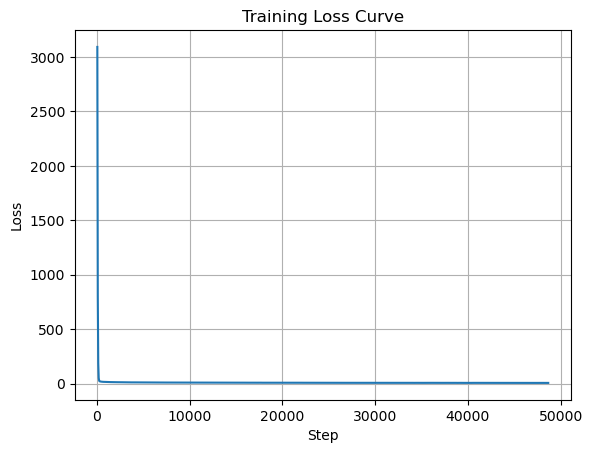

In [56]:
import matplotlib.pyplot as plt

# Sort by step to reconstruct the full training timeline
scalars_df = scalars_df.sort_values("step")

plt.figure()

plt.plot(scalars_df["step"], scalars_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()

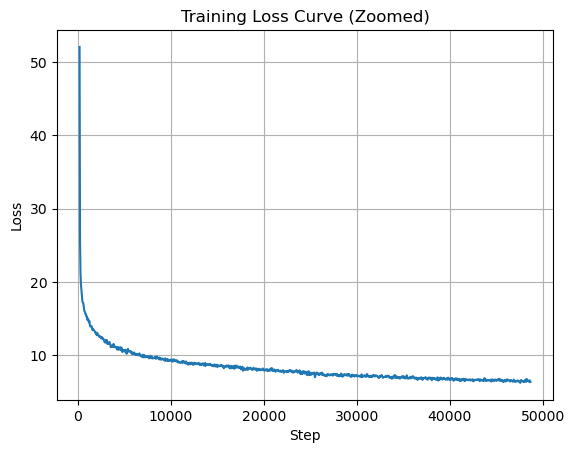

In [57]:
# Sort by step to keep correct order
scalars_df = scalars_df.sort_values("step")

# Filter out very large losses
filtered_df = scalars_df[scalars_df["loss"] < 100]

plt.figure()

plt.plot(filtered_df["step"], filtered_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Zoomed)")

plt.grid()

plt.show()

## List of metrics

In this step, I inspect which validation metrics are present in the scalar records.

In [58]:
# All nuScenes validation metric columns
metrics_cols = [

    # ===================== Car =====================
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_attr_err",

    # ===================== Global Errors =====================
    "NuScenes metric/pred_instances_3d_NuScenes/mATE",
    "NuScenes metric/pred_instances_3d_NuScenes/mASE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAOE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAVE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAAE",

    # ===================== Truck =====================
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err",

    # ===================== Construction Vehicle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err",

    # ===================== Bus =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err",

    # ===================== Trailer =====================
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err",

    # ===================== Barrier =====================
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err",

    # ===================== Motorcycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_attr_err",

    # ===================== Bicycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_attr_err",

    # ===================== Pedestrian =====================
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_attr_err",

    # ===================== Traffic Cone =====================
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_attr_err",

    # ===================== Summary =====================
    "NuScenes metric/pred_instances_3d_NuScenes/NDS",
    "NuScenes metric/pred_instances_3d_NuScenes/mAP",
]

In [59]:
prefix = "NuScenes metric/pred_instances_3d_NuScenes/"

rename_cols = {
    # Summary metrics
    prefix + "NDS": "NDS",
    prefix + "mAP": "mAP",
    prefix + "mATE": "mATE",
    prefix + "mASE": "mASE",
    prefix + "mAOE": "mAOE",
    prefix + "mAVE": "mAVE",
    prefix + "mAAE": "mAAE",
}

classes = [
    "car",
    "truck",
    "construction_vehicle",
    "bus",
    "trailer",
    "barrier",
    "motorcycle",
    "bicycle",
    "pedestrian",
    "traffic_cone",
]

for cls in classes:
    rename_cols[prefix + f"{cls}_AP_dist_0.5"] = f"{cls}_AP_0.5"
    rename_cols[prefix + f"{cls}_AP_dist_1.0"] = f"{cls}_AP_1.0"
    rename_cols[prefix + f"{cls}_AP_dist_2.0"] = f"{cls}_AP_2.0"
    rename_cols[prefix + f"{cls}_AP_dist_4.0"] = f"{cls}_AP_4.0"

    rename_cols[prefix + f"{cls}_trans_err"] = f"{cls}_ATE"
    rename_cols[prefix + f"{cls}_scale_err"] = f"{cls}_ASE"
    rename_cols[prefix + f"{cls}_orient_err"] = f"{cls}_AOE"
    rename_cols[prefix + f"{cls}_vel_err"] = f"{cls}_AVE"
    rename_cols[prefix + f"{cls}_attr_err"] = f"{cls}_AAE"
    
# Keep only metrics + useful identifiers
metrics_df = scalars_df[["run", "epoch", "step"] + metrics_cols].copy()

# Rename columns
metrics_df = metrics_df.rename(columns=rename_cols)

# Keep only validation/evaluation rows
metrics_df = metrics_df.dropna(subset=["NDS", "mAP"]).copy()

print(metrics_df.shape)
metrics_df.head(20)


(8, 100)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,0.9148,0.3421,0.5158,0.3186,1.1485,1.0185,0.3671,0.0396,0.1107,0.1925,0.2368,0.5617,0.2993,0.7311,0.9279,0.4022,0.0000,0.0028,0.0236,0.0382,0.8696,0.4851,1.5369,0.1729,0.3688,0.0661,0.1939,0.3297,0.3863,0.5960,0.2277,1.3168,2.4116,0.6458,0.0002,0.0137,0.0258,0.0696,0.7087,0.2966,1.3437,0.4894,0.2045,0.0619,0.1740,0.2142,0.2607,0.6213,0.3605,0.3225,NaN,NaN,0.0776,0.1373,0.1615,0.1725,0.4113,0.2847,1.4093,1.8322,0.4672,0.0000,0.0000,0.0000,0.0000,0.3787,0.3002,1.3751,0.3335,0.0511,0.3697,0.4879,0.5169,0.5481,0.4015,0.2985,1.5836,1.0658,0.4549,0.1541,0.1675,0.1835,0.2229,0.2801,0.4519,NaN,NaN,NaN,0.278986,0.198266
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,0.7783,0.2748,0.4556,0.2954,0.9540,0.9374,0.3018,0.0835,0.1993,0.2826,0.3239,0.4913,0.2574,0.5045,1.0611,0.4070,0.0000,0.0152,0.0561,0.1069,0.7865,0.4447,1.4301,0.1528,0.3395,0.1227,0.2941,0.4233,0.4492,0.5130,0.1923,0.6533,1.9168,0.5573,0.0111,0.0761,0.1137,0.1600,0.6305,0.2553,1.3726,0.4702,0.2290,0.0924,0.2351,0.2814,0.3258,0.5773,0.3672,0.2476,NaN,NaN,0.1672,0.2311,0.2516,0.2635,0.3381,0.2565,1.0213,1.8372,0.2361,0.0143,0.0172,0.0177,0.0193,0.2845,0.2940,1.3217,0.2937,0.0304,0.4324,0.5530,0.5863,0.6202,0.4063,0.2885,1.5208,0.9890,0.3406,0.2481,0.2644,0.2853,0.3361,0.2574,0.4216,NaN,NaN,NaN,0.337484,0.263817
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,0.6823,0.2316,0.4328,0.2893,0.8433,0.8315,0.2662,0.1090,0.2330,0.3121,0.3537,0.4599,0.2421,0.4180,0.7232,0.3204,0.0004,0.0239,0.0958,0.1474,0.7882,0.4339,1.2817,0.1441,0.3687,0.1552,0.3703,0.5175,0.5706,0.5018,0.1939,0.5497,1.6057,0.4377,0.0188,0.0917,0.1415,0.2004,0.6121,0.2483,1.3081,0.4166,0.1794,0.1593,0.3200,0.3739,0.4115,0.4765,0.3441,0.1931,NaN,NaN,0.1780,0.2347,0.2491,0.2585,0.3076,0.2638,0.8056,1.6662,0.2144,0.0561,0.0662,0.0682,0.0734,0.2746,0.2904,1.1210,0.4522,0.0477,0.4733,0.5725,0.6013,0.6317,0.3803,0.2916,1.5033,0.9616,0.3293,0.3173,0.3401,0.3624,0.4173,0.2579,0.4121,NaN,NaN,NaN,0.386113,0.304838
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,0.6238,0.2273,0.4180,0.2844,0.8277,0.7567,0.2723,0.1434,0.2859,0.3578,0.3986,0.4264,0.2369,0.3954,0.6753,0.3516,0.0000,0.0154,0.0827,0.1762,0.8974,0.4586,1.5577,0.1533,0.3294,0.2361,0.4466,0.5934,0.6412,0.4311,0.1900,0.5164,1.3846,0.4549,0.0426,0.1653,0.2242,0.2880,0.5711,0.2171,1.2549,0.4549,0.2072,0.1857,0.3428,0.4143,0.4577,0.4793,0.3448,0.2380,NaN,NaN,0.2249,0.2922,0.3123,0.3174,0.3009,0.2504,0.7180,1.4437,0.2498,0.0732,0.0813,0.0819,0.0830,0.2592,0.2796,0.9651,0.3965

**Observations**: 

I’m not seeing a bug with checkpointing or resume, those are working fine. The missing NDS values happen because of the Slurm time limit.

Each epoch runs: training → save checkpoint → validation. Sometimes the job hits the 6-hour limit after training and saving, but before validation finishes. When that happens, the checkpoint exists, but no NDS is logged.

When I resume, training continues normally and validation completes for a later epoch. That’s why I only get NDS for epochs 1, 3, and 5—epochs 2 and 4 were interrupted during validation.

## NDS and mAP

In this step, I plot the NDS (nuScenes Detection Score) over the validation steps. This shows how the model performance improves across epochs. Unlike training loss, this curve reflects actual detection quality on the validation set.

Metrics:
* ```NDS``` (nuScenes Detection Score) is the main benchmark metric that combines detection accuracy and prediction quality into a single score. It includes mAP together with five true-positive metrics: translation error (mATE), scale error (mASE), orientation error (mAOE), velocity error (mAVE), and attribute error (mAAE). While mAP measures whether objects are detected and approximately localized, NDS additionally evaluates how accurate the predicted 3D box position, size, orientation, motion, and semantic attributes are.
* nuScenes ```mAP``` measures how well a model detects objects across different localization accuracies. A prediction is considered correct if the predicted object center is within one of four distance thresholds (0.5m, 1m, 2m, 4m) from the ground-truth center on the ground plane. AP is computed for each class and threshold, and the final mAP is the average over all classes and thresholds. Using multiple thresholds allows nuScenes to evaluate both object detection capability and localization precision.

**Source**: https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/eval/detection/README.md



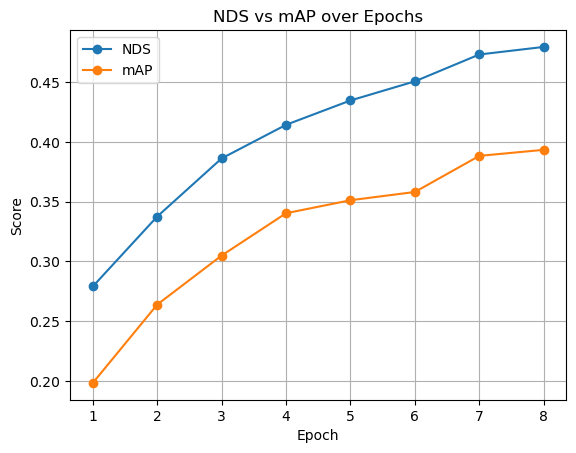

In [60]:
# Plot both curves
plt.plot(metrics_df["step"], metrics_df["NDS"], marker="o", label="NDS")
plt.plot(metrics_df["step"], metrics_df["mAP"], marker="o", label="mAP")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("NDS vs mAP over Epochs")

plt.legend()
plt.grid()

plt.show()

**Observations:** Both NDS and mAP increase steadily across all training epochs, indicating continuous improvement of the LiDAR-only baseline during training. The strongest gains occur during the first epochs, while the improvement rate becomes more gradual afterward. Unlike the BEVFusion experiment, no clear plateau is observed within the first 5 epochs, suggesting that the model may still benefit from additional training epochs.

## Global errors
* ```mATE``` (mean Average Translation Error) measures the average localization error between the predicted and ground-truth object centers on the ground plane, in meters. Lower values indicate more accurate object positioning.
* ```mASE``` (mean Average Scale Error) measures the error in predicted object size using 1 − IoU after aligning translation and orientation. Lower values indicate more accurate object dimensions.
* ```mAOE``` (mean Average Orientation Error) measures the average difference in yaw angle between predicted and ground-truth bounding boxes, in radians. Lower values indicate more accurate orientation estimation.
* ```mAVE``` (mean Average Velocity Error) measures the average error in predicted object velocity, computed as the L2 distance between predicted and ground-truth velocities in m/s. Lower values indicate more accurate motion estimation.
* ```mAAE``` (mean Average Attribute Error) measures the error in semantic attribute prediction, defined as 1 − attribute classification accuracy. Lower values indicate better attribute prediction (e.g., moving, parked, standing).

**Source:** https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html

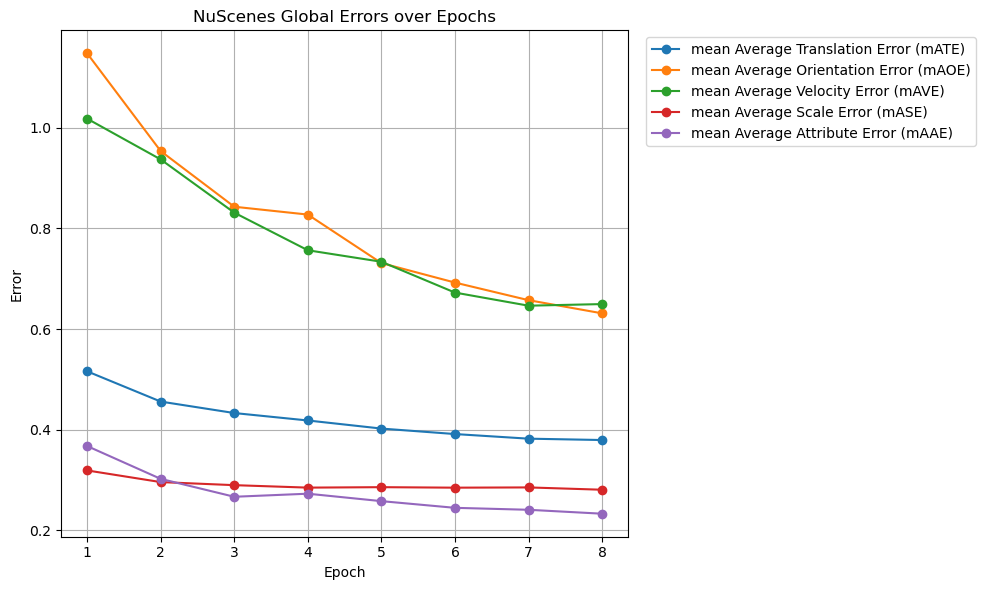

In [66]:
plt.figure(figsize=(10, 6))

# Plot curves
plt.plot(metrics_df["step"], metrics_df["mATE"], marker="o",
         label="mean Average Translation Error (mATE)")

plt.plot(metrics_df["step"], metrics_df["mAOE"], marker="o",
         label="mean Average Orientation Error (mAOE)")

plt.plot(metrics_df["step"], metrics_df["mAVE"], marker="o",
         label="mean Average Velocity Error (mAVE)")

plt.plot(metrics_df["step"], metrics_df["mASE"], marker="o",
         label="mean Average Scale Error (mASE)")

plt.plot(metrics_df["step"], metrics_df["mAAE"], marker="o",
         label="mean Average Attribute Error (mAAE)")

# Labels
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("NuScenes Global Errors over Epochs")

# Put legend outside
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid()

# Prevent clipping
plt.tight_layout()

plt.show()

In [67]:
last_row = metrics_df.iloc[-1]

print("Global detection metrics:")
print(f"NuScenes Detection Score (NDS)       : {last_row['NDS']:.4f}")
print(f"mean Average Precision (mAP)         : {last_row['mAP']:.4f}")

print("\nGlobal error metrics:")
print(f"mean Average Translation Error (mATE): {last_row['mATE']:.4f}")
print(f"mean Average Scale Error (mASE)      : {last_row['mASE']:.4f}")
print(f"mean Average Orientation Error (mAOE): {last_row['mAOE']:.4f}")
print(f"mean Average Velocity Error (mAVE)   : {last_row['mAVE']:.4f}")
print(f"mean Average Attribute Error (mAAE)  : {last_row['mAAE']:.4f}")


Global detection metrics:
NuScenes Detection Score (NDS)       : 0.4794
mean Average Precision (mAP)         : 0.3933

Global error metrics:
mean Average Translation Error (mATE): 0.3791
mean Average Scale Error (mASE)      : 0.2802
mean Average Orientation Error (mAOE): 0.6312
mean Average Velocity Error (mAVE)   : 0.6496
mean Average Attribute Error (mAAE)  : 0.2325


**Observations:** Most error metrics decrease steadily during training, showing improved detection performance over epochs. The largest improvements occur during the first epochs, while the curves become more stable after epoch 3. Orientation and velocity errors (mAOE and mAVE) show the strongest improvements, whereas scale error (mASE) changes only slightly during training.

In [68]:
metrics_df.head()

,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,0.9148,0.3421,0.5158,0.3186,1.1485,1.0185,0.3671,0.0396,0.1107,0.1925,0.2368,0.5617,0.2993,0.7311,0.9279,0.4022,0.0000,0.0028,0.0236,0.0382,0.8696,0.4851,1.5369,0.1729,0.3688,0.0661,0.1939,0.3297,0.3863,0.5960,0.2277,1.3168,2.4116,0.6458,0.0002,0.0137,0.0258,0.0696,0.7087,0.2966,1.3437,0.4894,0.2045,0.0619,0.1740,0.2142,0.2607,0.6213,0.3605,0.3225,NaN,NaN,0.0776,0.1373,0.1615,0.1725,0.4113,0.2847,1.4093,1.8322,0.4672,0.0000,0.0000,0.0000,0.0000,0.3787,0.3002,1.3751,0.3335,0.0511,0.3697,0.4879,0.5169,0.5481,0.4015,0.2985,1.5836,1.0658,0.4549,0.1541,0.1675,0.1835,0.2229,0.2801,0.4519,NaN,NaN,NaN,0.278986,0.198266
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,0.7783,0.2748,0.4556,0.2954,0.9540,0.9374,0.3018,0.0835,0.1993,0.2826,0.3239,0.4913,0.2574,0.5045,1.0611,0.4070,0.0000,0.0152,0.0561,0.1069,0.7865,0.4447,1.4301,0.1528,0.3395,0.1227,0.2941,0.4233,0.4492,0.5130,0.1923,0.6533,1.9168,0.5573,0.0111,0.0761,0.1137,0.1600,0.6305,0.2553,1.3726,0.4702,0.2290,0.0924,0.2351,0.2814,0.3258,0.5773,0.3672,0.2476,NaN,NaN,0.1672,0.2311,0.2516,0.2635,0.3381,0.2565,1.0213,1.8372,0.2361,0.0143,0.0172,0.0177,0.0193,0.2845,0.2940,1.3217,0.2937,0.0304,0.4324,0.5530,0.5863,0.6202,0.4063,0.2885,1.5208,0.9890,0.3406,0.2481,0.2644,0.2853,0.3361,0.2574,0.4216,NaN,NaN,NaN,0.337484,0.263817
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,0.6823,0.2316,0.4328,0.2893,0.8433,0.8315,0.2662,0.1090,0.2330,0.3121,0.3537,0.4599,0.2421,0.4180,0.7232,0.3204,0.0004,0.0239,0.0958,0.1474,0.7882,0.4339,1.2817,0.1441,0.3687,0.1552,0.3703,0.5175,0.5706,0.5018,0.1939,0.5497,1.6057,0.4377,0.0188,0.0917,0.1415,0.2004,0.6121,0.2483,1.3081,0.4166,0.1794,0.1593,0.3200,0.3739,0.4115,0.4765,0.3441,0.1931,NaN,NaN,0.1780,0.2347,0.2491,0.2585,0.3076,0.2638,0.8056,1.6662,0.2144,0.0561,0.0662,0.0682,0.0734,0.2746,0.2904,1.1210,0.4522,0.0477,0.4733,0.5725,0.6013,0.6317,0.3803,0.2916,1.5033,0.9616,0.3293,0.3173,0.3401,0.3624,0.4173,0.2579,0.4121,NaN,NaN,NaN,0.386113,0.304838
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,0.6238,0.2273,0.4180,0.2844,0.8277,0.7567,0.2723,0.1434,0.2859,0.3578,0.3986,0.4264,0.2369,0.3954,0.6753,0.3516,0.0000,0.0154,0.0827,0.1762,0.8974,0.4586,1.5577,0.1533,0.3294,0.2361,0.4466,0.5934,0.6412,0.4311,0.1900,0.5164,1.3846,0.4549,0.0426,0.1653,0.2242,0.2880,0.5711,0.2171,1.2549,0.4549,0.2072,0.1857,0.3428,0.4143,0.4577,0.4793,0.3448,0.2380,NaN,NaN,0.2249,0.2922,0.3123,0.3174,0.3009,0.2504,0.7180,1.4437,0.2498,0.0732,0.0813,0.0819,0.0830,0.2592,0.2796,0.9651,0.3965

In [70]:
classes = [
    "car", "truck", "bus", "trailer", "construction_vehicle",
    "pedestrian", "motorcycle", "bicycle", "traffic_cone", "barrier"
]

last = metrics_df.iloc[-1]

per_class_df = pd.DataFrame(index=classes)

# Average Precision
per_class_df["Average Precision (AP)"] = [
    last[[f"{cls}_AP_0.5", f"{cls}_AP_1.0", f"{cls}_AP_2.0", f"{cls}_AP_4.0"]].mean()
    for cls in classes
]

# Error metrics
per_class_df["Translation Error (ATE)"] = [last[f"{cls}_ATE"] for cls in classes]
per_class_df["Scale Error (ASE)"] = [last[f"{cls}_ASE"] for cls in classes]
per_class_df["Orientation Error (AOE)"] = [last[f"{cls}_AOE"] for cls in classes]
per_class_df["Velocity Error (AVE)"] = [last[f"{cls}_AVE"] for cls in classes]
per_class_df["Attribute Error (AAE)"] = [last[f"{cls}_AAE"] for cls in classes]

per_class_df = per_class_df.round(3)

per_class_df = per_class_df.sort_values(
    by="Average Precision (AP)",
    ascending=False
)

per_class_df

,Average Precision (AP),Translation Error (ATE),Scale Error (ASE),Orientation Error (AOE),Velocity Error (AVE),Attribute Error (AAE)
car,0.739,0.234,0.167,0.283,0.540,0.214
pedestrian,0.700,0.260,0.291,0.996,0.620,0.240
bus,0.549,0.403,0.185,0.239,1.404,0.394
traffic_cone,0.429,0.239,0.401,NaN,NaN,NaN
motorcycle,0.364,0.264,0.252,0.535,1.177,0.248
truck,0.361,0.384,0.216,0.316,0.486,0.265
barrier,0.341,0.408,0.332,0.184,NaN,NaN
trailer,0.189,0.573,0.231,1.094,0.461,0.145
bicycle,0.163,0.232,0.279,0.756,0.357,0.024
construction_vehicle,0.098,0.794,0.450,1.279,0.152,0.331


**Observations:** Detection performance varies across object classes, with cars and pedestrians achieving the highest Average Precision (AP) values among the main dynamic objects. Construction vehicles, bicycles, and trailers remain the most difficult classes to detect, showing lower AP and higher translation error (ATE) and orientation error (AOE). Velocity error (AVE) is particularly high for buses and motorcycles, indicating more difficulty in motion estimation for these classes. Traffic cones and barriers do not include orientation, velocity, or attribute metrics because these properties are not defined for these object types in the nuScenes evaluation.